# EDA — Physics Problems (Dataset 2026-05-15)

> **Dataset:** `EXACT_Materials/Datasets/EXACT2026_dataset_2026-05-15/Physics_Problems_Text_Only.csv`  
> **Rows:** 1,352 | **Columns:** `id`, `question`, `cot`, `answer`, `unit`  
> **Date:** 2026-05-17

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

%matplotlib inline

In [2]:
# ── Load dataset ──
DATA_PATH = Path("../../EXACT_Materials/Datasets/EXACT2026_dataset_2026-05-15/Physics_Problems_Text_Only/Physics_Problems_Text_Only.csv")
df = pd.read_csv(DATA_PATH)

# ── Derived columns ──
df["prefix"] = df["id"].str.extract(r"^([A-Z]+)")
df["answer_numeric"] = pd.to_numeric(df["answer"], errors="coerce")
df["q_len"] = df["question"].str.len()
df["q_words"] = df["question"].str.split().str.len()
df["cot_len"] = df["cot"].str.len()
df["cot_steps"] = df["cot"].str.count(r"Step \d+")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (1352, 11)
Columns: ['id', 'question', 'cot', 'answer', 'unit', 'prefix', 'answer_numeric', 'q_len', 'q_words', 'cot_len', 'cot_steps']


,id,question,cot,answer,unit,prefix,answer_numeric,q_len,q_words,cot_len,cot_steps
0,TD401,Calculate the energy stored in capacitor C whe...,Step 1: Identify the given values for capacita...,0.045,J,TD,0.045,72,17,336,4
1,TD402,"Calculate the capacitance C of the capacitor, ...",Step 1: Identify the given values from the que...,100,μF,TD,100.000,110,23,320,4
2,LD001,"Two charges, q1 = 6 × 10^-8 C and q2 = -6 × 10...",Step 1: Identify the given charges and distanc...,0.05,N,LD,0.050,221,57,316,4


---
## 1. Basic Info & Null Check

In [3]:
print("=== Data Types ===")
print(df[["id","question","cot","answer","unit"]].dtypes)
print()

print("=== Null Values ===")
null_counts = df[["id","question","cot","answer","unit"]].isnull().sum()
print(null_counts)
print()

print("=== Empty Strings ===")
for col in ["id","question","cot","answer","unit"]:
    empty = (df[col].astype(str).str.strip() == "").sum()
    if empty > 0:
        print(f"  {col}: {empty} empty strings")
    else:
        print(f"  {col}: OK")

=== Data Types ===
id          str
question    str
cot         str
answer      str
unit        str
dtype: object

=== Null Values ===
id           0
question     0
cot          0
answer       0
unit        14
dtype: int64

=== Empty Strings ===
  id: OK
  question: OK
  cot: OK
  answer: OK
  unit: OK


In [4]:
# 14 rows with null unit — need manual fix or BTC report
null_unit = df[df["unit"].isna()][["id", "question", "answer", "prefix"]].copy()
null_unit["question"] = null_unit["question"].str[:100] + "..."
print(f"Rows with null unit: {len(null_unit)}")
null_unit

Rows with null unit: 14


,id,question,answer,prefix
113,TD013,A parallel-plate capacitor with a capacitance ...,5.28,TD
228,DT047,A charge q is placed at point O in the air. Ox...,1/2 . (1/ \sqrt{E_A} + 1/ \sqrt{E_B}),DT
610,TD369,A capacitor with a capacitance of 5 μF is char...,Do not change,TD
614,TD373,A capacitor has a voltage of 10 V and a capaci...,50%,TD
618,TD377,A capacitor has a charge Q = 50 μC and a capac...,the voltage is halfed,TD
621,TD380,A capacitor has a charge of 90 μC and a voltag...,decreases by 4 times,TD
627,TD386,A parallel-plate capacitor is placed in a diel...,decreases by half,TD
968,DDT327,"For an RLC circuit with R = 12 Ω and Z = 20 Ω,...",0.60,DDT
978,DDT337,An RLC series circuit has R = 18 Ω and Z = 30 ...,0.60,DDT
984,DDT343,"Given a series RLC circuit has R = 16 Ω, Z = 4...",0.40,DDT


---
## 2. Domain Distribution (ID Prefix)

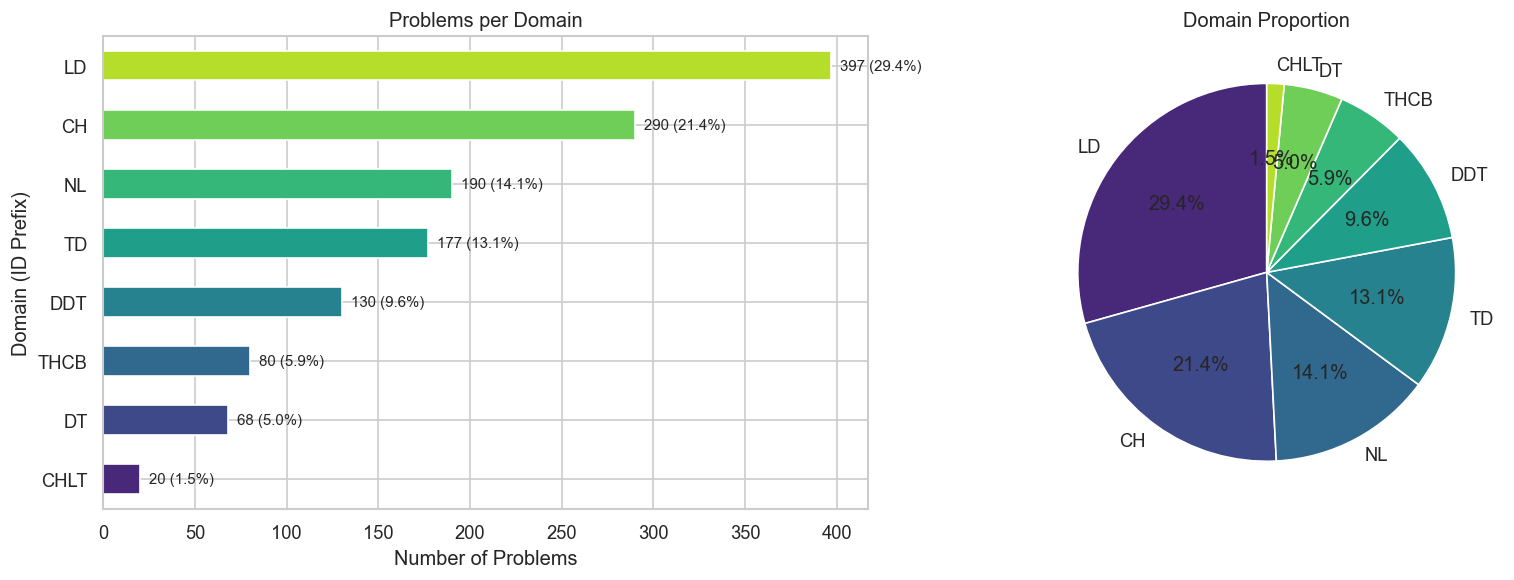


Imbalance ratio (max/min): 19.85


In [5]:
prefix_counts = df["prefix"].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette("viridis", len(prefix_counts))
prefix_counts.plot.barh(ax=axes[0], color=colors)
axes[0].set_xlabel("Number of Problems")
axes[0].set_ylabel("Domain (ID Prefix)")
axes[0].set_title("Problems per Domain")
for i, (val, name) in enumerate(zip(prefix_counts.values, prefix_counts.index)):
    axes[0].text(val + 5, i, f"{val} ({val/len(df)*100:.1f}%)", va="center", fontsize=9)

# Pie chart
prefix_counts_desc = prefix_counts.sort_values(ascending=False)
axes[1].pie(
    prefix_counts_desc.values, 
    labels=prefix_counts_desc.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis", len(prefix_counts_desc))
)
axes[1].set_title("Domain Proportion")

plt.tight_layout()
plt.savefig("../../app/figures/EDA_domain_distribution.png", bbox_inches="tight")
plt.show()

print("\nImbalance ratio (max/min):", prefix_counts.max() / prefix_counts.min())

---
## 3. Answer Type Classification

**Key finding:** 28% of answers are NOT pure numeric — scientific notation, text, Yes/No, multi-value, sqrt.

In [6]:
def classify_answer(ans: str) -> str:
    """Classify answer into one of 7 categories."""
    ans = str(ans).strip()
    if ans in ("Yes", "No"):
        return "yes_no"
    try:
        float(ans)
        return "pure_numeric"
    except ValueError:
        pass
    if re.search(r"10\^|10[\u2070-\u2079\u207B]", ans):
        return "scientific_notation"
    if "sqrt" in ans or "\\sqrt" in ans:
        return "contains_sqrt"
    if ";" in ans:
        return "multi_value"
    if not any(c.isdigit() for c in ans):
        return "text_only"
    if any(c.isalpha() for c in ans):
        return "mixed_text_number"
    return "other"

df["answer_type"] = df["answer"].apply(classify_answer)

type_counts = df["answer_type"].value_counts()
print("=== Answer Type Distribution ===")
for t, c in type_counts.items():
    print(f"  {t:25s} {c:5d}  ({c/len(df)*100:5.1f}%)")
print(f"  {'TOTAL':25s} {len(df):5d}")
print(f"\n  Non-numeric total: {len(df) - type_counts.get('pure_numeric', 0)} ({(len(df) - type_counts.get('pure_numeric', 0))/len(df)*100:.1f}%)")

=== Answer Type Distribution ===
  pure_numeric                973  ( 72.0%)
  scientific_notation         237  ( 17.5%)
  text_only                    50  (  3.7%)
  mixed_text_number            37  (  2.7%)
  multi_value                  25  (  1.8%)
  yes_no                       21  (  1.6%)
  contains_sqrt                 6  (  0.4%)
  other                         3  (  0.2%)
  TOTAL                      1352

  Non-numeric total: 379 (28.0%)


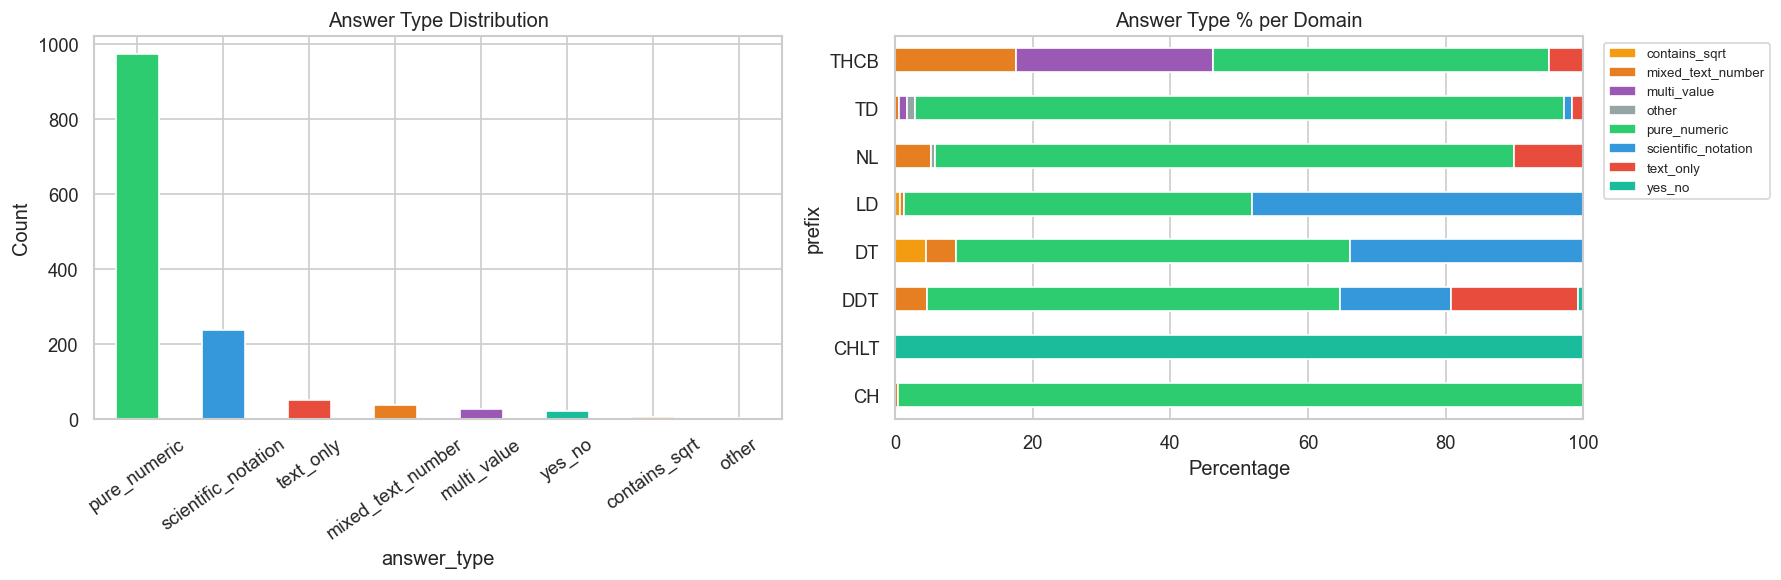

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall answer type distribution
type_order = type_counts.index.tolist()
palette = {
    "pure_numeric": "#2ecc71", "scientific_notation": "#3498db",
    "text_only": "#e74c3c", "mixed_text_number": "#e67e22",
    "multi_value": "#9b59b6", "yes_no": "#1abc9c",
    "contains_sqrt": "#f39c12", "other": "#95a5a6"
}
colors_list = [palette.get(t, "#95a5a6") for t in type_order]
type_counts.plot.bar(ax=axes[0], color=colors_list)
axes[0].set_title("Answer Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)

# Stacked bar per domain
ct = pd.crosstab(df["prefix"], df["answer_type"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot.barh(
    stacked=True, ax=axes[1],
    color=[palette.get(c, "#95a5a6") for c in ct_pct.columns]
)
axes[1].set_title("Answer Type % per Domain")
axes[1].set_xlabel("Percentage")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("../../app/figures/EDA_answer_types.png", bbox_inches="tight")
plt.show()

In [8]:
# Crosstab: answer type vs domain — key for pipeline routing
ct = pd.crosstab(df["prefix"], df["answer_type"], margins=True)
print("=== Answer Type × Domain Crosstab ===")
ct

=== Answer Type × Domain Crosstab ===


answer_type,contains_sqrt,mixed_text_number,multi_value,other,pure_numeric,scientific_notation,text_only,yes_no,All
prefix,,,,,,,,,
CH,0,1,0,0,289,0,0,0,290
CHLT,0,0,0,0,0,0,0,20,20
DDT,0,6,0,0,78,21,24,1,130
DT,3,3,0,0,39,23,0,0,68
LD,3,2,0,0,201,191,0,0,397
NL,0,10,0,1,160,0,19,0,190
TD,0,1,2,2,167,2,3,0,177
THCB,0,14,23,0,39,0,4,0,80
All,6,37,25,3,973,237,50,21,1352


### 3.1 Non-numeric Answer Samples

Show examples of each non-numeric type to understand what the model needs to output.

In [9]:
for atype in ["scientific_notation", "text_only", "mixed_text_number", "multi_value", "yes_no", "contains_sqrt"]:
    sub = df[df["answer_type"] == atype][["id", "answer", "unit", "prefix"]].head(5)
    print(f"\n--- {atype} ({len(df[df['answer_type'] == atype])} total) ---")
    for _, row in sub.iterrows():
        print(f"  [{row['id']}] {row['answer']:50s}  unit={row['unit']}")


--- scientific_notation (237 total) ---
  [LD002] 24.45 × 10^-3                                       unit=N
  [LD004] 5.234 × 10^-3                                       unit=N
  [LD005] 9\sqrt{3} × 10^-27                                  unit=N
  [LD006] 1.23 × 10^-3                                        unit=N
  [LD027] 30.24 × 10^-3                                       unit=N

--- text_only (50 total) ---
  [TD369] Do not change                                       unit=nan
  [TD377] the voltage is halfed                               unit=nan
  [TD386] decreases by half                                   unit=nan
  [THCB071] Resistance decreases → current increases.           unit=—
  [THCB073] The lamp shines brighter because the current through it increases.  unit=—

--- mixed_text_number (37 total) ---
  [LD047] Hướng về phía q₂                                    unit=-
  [LD077] E1 = (3/4)E2                                        unit=-
  [DT008] /frac{2k \abs{q} h}{(a^2 + 

---
## 4. Unit Analysis

Total unique units: 55
Null units: 14



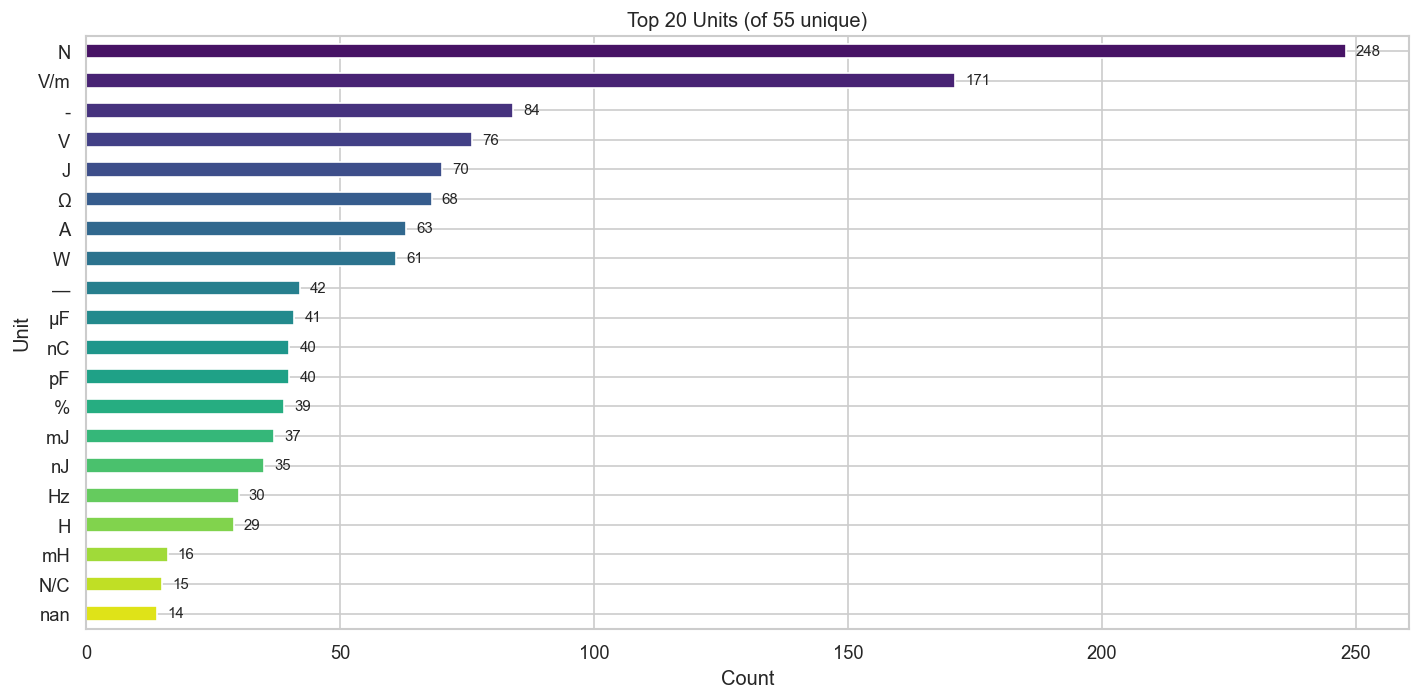

In [10]:
unit_counts = df["unit"].value_counts(dropna=False)

print(f"Total unique units: {df['unit'].nunique()}")
print(f"Null units: {df['unit'].isna().sum()}")
print()

# Top 20 units
fig, ax = plt.subplots(figsize=(12, 6))
top_units = unit_counts.head(20)
top_units.plot.barh(ax=ax, color=sns.color_palette("viridis", len(top_units)))
ax.set_xlabel("Count")
ax.set_ylabel("Unit")
ax.set_title(f"Top 20 Units (of {df['unit'].nunique()} unique)")
ax.invert_yaxis()
for i, val in enumerate(top_units.values):
    ax.text(val + 2, i, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../../app/figures/EDA_unit_distribution.png", bbox_inches="tight")
plt.show()

In [11]:
# ── Unit inconsistencies ──

# 1. Dash variants: - (U+002D) vs — (U+2014)
dash_df = df[df["unit"].isin(["-", "\u2014"])]
print("=== Dash Unit Variants ===")
print(pd.crosstab(dash_df["prefix"], dash_df["unit"]))
print(f"Total dash-unit rows: {len(dash_df)}")
print()

# 2. Mu/micro: μ (U+03BC) vs µ (U+00B5)
mu_greek = df["unit"].str.contains(chr(956), na=False).sum()   # μ U+03BC
mu_micro = df["unit"].str.contains(chr(181), na=False).sum()   # µ U+00B5
print(f"=== Mu/Micro Inconsistency ===")
print(f"  \u03bcF (Greek mu U+03BC): {mu_greek}")
print(f"  \u00b5F (Micro sign U+00B5): {mu_micro}")
print()

# 3. Vietnamese remnants
viet_unit = df[df["unit"].str.contains("lần|Độ", na=False, regex=True)]
print(f"=== Vietnamese in Units: {len(viet_unit)} ===")
if len(viet_unit) > 0:
    print(viet_unit[["id", "answer", "unit"]].to_string())
print()

# 4. Multi-unit format
multi_unit = df[df["unit"].str.contains(";", na=False)]
print(f"=== Multi-Unit Answers: {len(multi_unit)} ===")
print(multi_unit["unit"].value_counts().to_string())

=== Dash Unit Variants ===
unit     -   —
prefix        
CH      41   0
CHLT    20   0
DDT      0  27
LD       4   0
NL      19   7
TD       0   4
THCB     0   4
Total dash-unit rows: 126

=== Mu/Micro Inconsistency ===
  μF (Greek mu U+03BC): 64
  µF (Micro sign U+00B5): 14

=== Vietnamese in Units: 2 ===
        id answer unit
608  TD367      4  lần
808  NL127      4  lần

=== Multi-Unit Answers: 25 ===
unit
cm; %      7
cm; cm     3
g; g       3
A; A       2
kg; %      2
°C; °C     2
μC; μJ     1
μJ; μC     1
A; A; A    1
m; %       1
°C; %      1
V; V       1


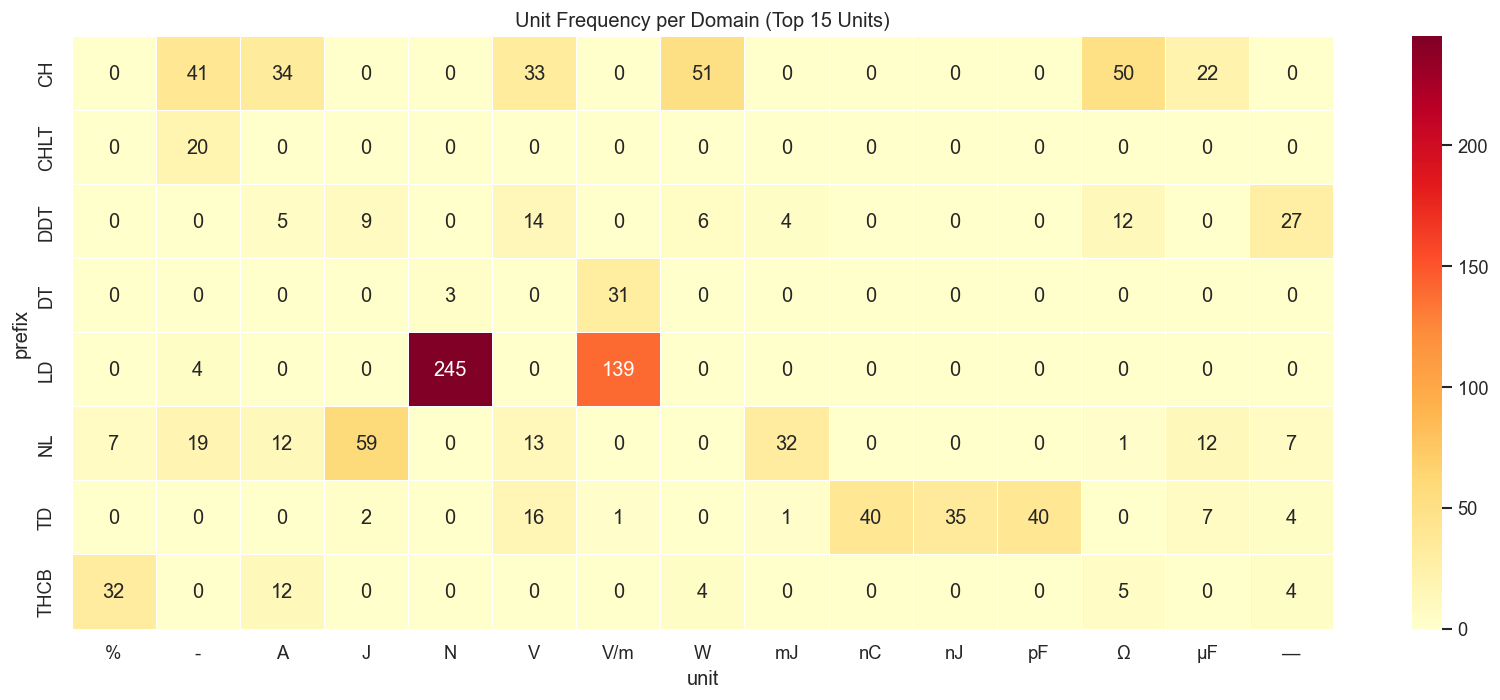

In [12]:
# Heatmap: unit frequency per domain
# Only top 15 units to keep readable
top_15_units = df["unit"].value_counts().head(15).index.tolist()
sub = df[df["unit"].isin(top_15_units)]
ct_unit = pd.crosstab(sub["prefix"], sub["unit"])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct_unit, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Unit Frequency per Domain (Top 15 Units)")
plt.tight_layout()
plt.savefig("../../app/figures/EDA_unit_heatmap.png", bbox_inches="tight")
plt.show()

---
## 5. Numeric Answer Analysis

In [13]:
numeric = df[df["answer_type"] == "pure_numeric"].copy()
print(f"Pure numeric answers: {len(numeric)} / {len(df)} ({len(numeric)/len(df)*100:.1f}%)")
print()
print("=== Descriptive Stats ===")
print(numeric["answer_numeric"].describe())
print()

# Magnitude distribution
print("=== Magnitude Distribution ===")
bins = [-np.inf, -1, 0, 1, 10, 100, 1000, 1e6, np.inf]
labels = ["<-1", "-1 to 0", "0 to 1", "1-10", "10-100", "100-1K", "1K-1M", ">1M"]
numeric["magnitude"] = pd.cut(numeric["answer_numeric"], bins=bins, labels=labels)
mag_counts = numeric["magnitude"].value_counts().sort_index()
for label, count in mag_counts.items():
    print(f"  {label:12s}: {count:4d}  ({count/len(numeric)*100:5.1f}%)")

Pure numeric answers: 973 / 1352 (72.0%)

=== Descriptive Stats ===
count    9.730000e+02
mean     1.494135e+04
std      2.438867e+05
min     -1.770000e+00
25%      1.200000e+00
50%      1.000000e+01
75%      8.660000e+01
max      6.300000e+06
Name: answer_numeric, dtype: float64

=== Magnitude Distribution ===
  <-1         :    1  (  0.1%)
  -1 to 0     :   18  (  1.8%)
  0 to 1      :  215  ( 22.1%)
  1-10        :  255  ( 26.2%)
  10-100      :  273  ( 28.1%)
  100-1K      :  172  ( 17.7%)
  1K-1M       :   36  (  3.7%)
  >1M         :    3  (  0.3%)


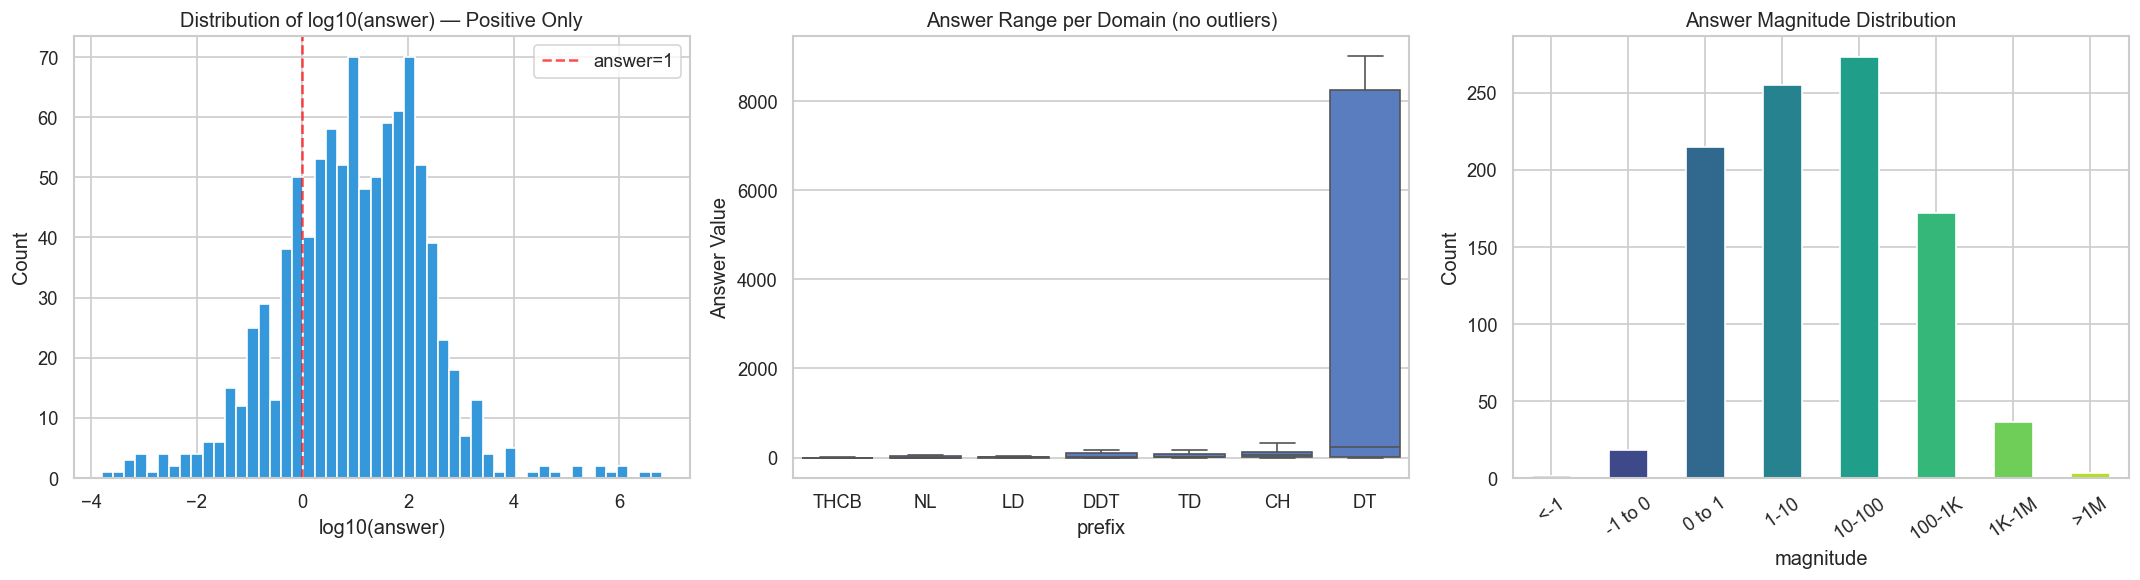

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log-scale histogram of all numeric answers
valid = numeric["answer_numeric"][numeric["answer_numeric"] > 0]
axes[0].hist(np.log10(valid), bins=50, color="#3498db", edgecolor="white")
axes[0].set_xlabel("log10(answer)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of log10(answer) — Positive Only")
axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.7, label="answer=1")
axes[0].legend()

# Box plot per domain
domain_order = numeric.groupby("prefix")["answer_numeric"].median().sort_values().index
sns.boxplot(
    data=numeric, x="prefix", y="answer_numeric",
    order=domain_order, ax=axes[1], showfliers=False
)
axes[1].set_title("Answer Range per Domain (no outliers)")
axes[1].set_ylabel("Answer Value")

# Magnitude bar chart
mag_counts.plot.bar(ax=axes[2], color=sns.color_palette("viridis", len(mag_counts)))
axes[2].set_title("Answer Magnitude Distribution")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("../../app/figures/EDA_numeric_distribution.png", bbox_inches="tight")
plt.show()

In [15]:
# Per-domain numeric stats
print("=== Numeric Answer Stats per Domain ===")
stats = numeric.groupby("prefix")["answer_numeric"].agg(["count","min","median","mean","max","std"])
stats = stats.round(2)
stats

=== Numeric Answer Stats per Domain ===


,count,min,median,mean,max,std
prefix,,,,,,
CH,289,0.04,53.05,115.63,1600.0,195.97
DDT,78,0.00,16.02,317.14,4000.0,853.79
DT,39,0.00,245.91,355049.36,6300000.0,1180120.00
LD,201,0.00,7.82,3014.07,432000.0,31002.56
NL,160,0.00,0.90,86.68,1800.0,244.70
TD,167,-1.77,20.33,78.49,1200.0,151.22
THCB,39,0.10,0.83,1.43,10.0,1.78


---
## 6. Question & CoT Analysis

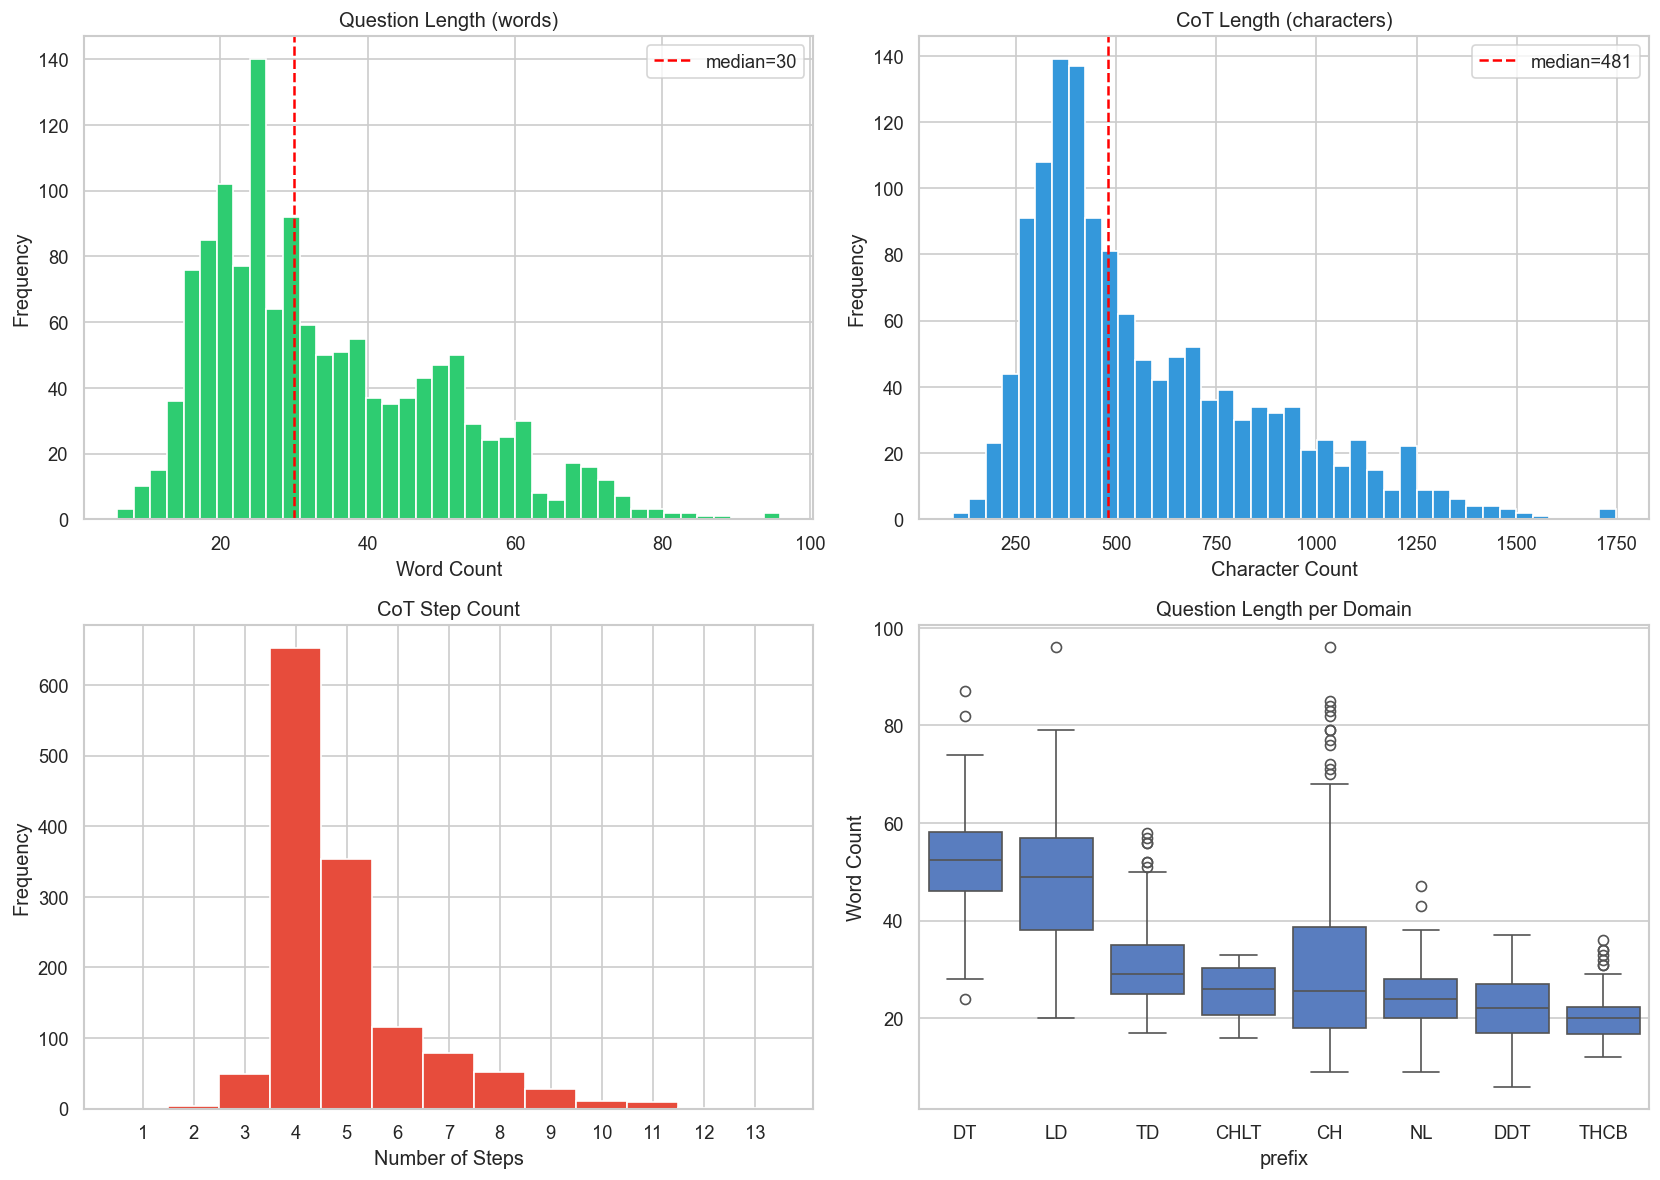

Question — words: mean=34, median=30, max=96
CoT — chars: mean=581, median=481, max=1747
CoT — steps: mean=4.9, median=4, max=13


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Question word count distribution
axes[0, 0].hist(df["q_words"], bins=40, color="#2ecc71", edgecolor="white")
axes[0, 0].set_xlabel("Word Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Question Length (words)")
axes[0, 0].axvline(df["q_words"].median(), color="red", linestyle="--", label=f"median={df['q_words'].median():.0f}")
axes[0, 0].legend()

# CoT length distribution
axes[0, 1].hist(df["cot_len"], bins=40, color="#3498db", edgecolor="white")
axes[0, 1].set_xlabel("Character Count")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("CoT Length (characters)")
axes[0, 1].axvline(df["cot_len"].median(), color="red", linestyle="--", label=f"median={df['cot_len'].median():.0f}")
axes[0, 1].legend()

# CoT steps distribution
axes[1, 0].hist(df["cot_steps"], bins=range(1, 15), color="#e74c3c", edgecolor="white", align="left")
axes[1, 0].set_xlabel("Number of Steps")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("CoT Step Count")
axes[1, 0].set_xticks(range(1, 14))

# Q words by domain
domain_order = df.groupby("prefix")["q_words"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="prefix", y="q_words", order=domain_order, ax=axes[1, 1])
axes[1, 1].set_title("Question Length per Domain")
axes[1, 1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig("../../app/figures/EDA_question_cot_length.png", bbox_inches="tight")
plt.show()

print(f"Question — words: mean={df['q_words'].mean():.0f}, median={df['q_words'].median():.0f}, max={df['q_words'].max()}")
print(f"CoT — chars: mean={df['cot_len'].mean():.0f}, median={df['cot_len'].median():.0f}, max={df['cot_len'].max()}")
print(f"CoT — steps: mean={df['cot_steps'].mean():.1f}, median={df['cot_steps'].median():.0f}, max={df['cot_steps'].max()}")

C:\Users\PC\AppData\Local\Temp\ipykernel_21644\3301008530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="prefix", y="cot_steps", order=domain_order, ax=ax, palette="coolwarm_r")


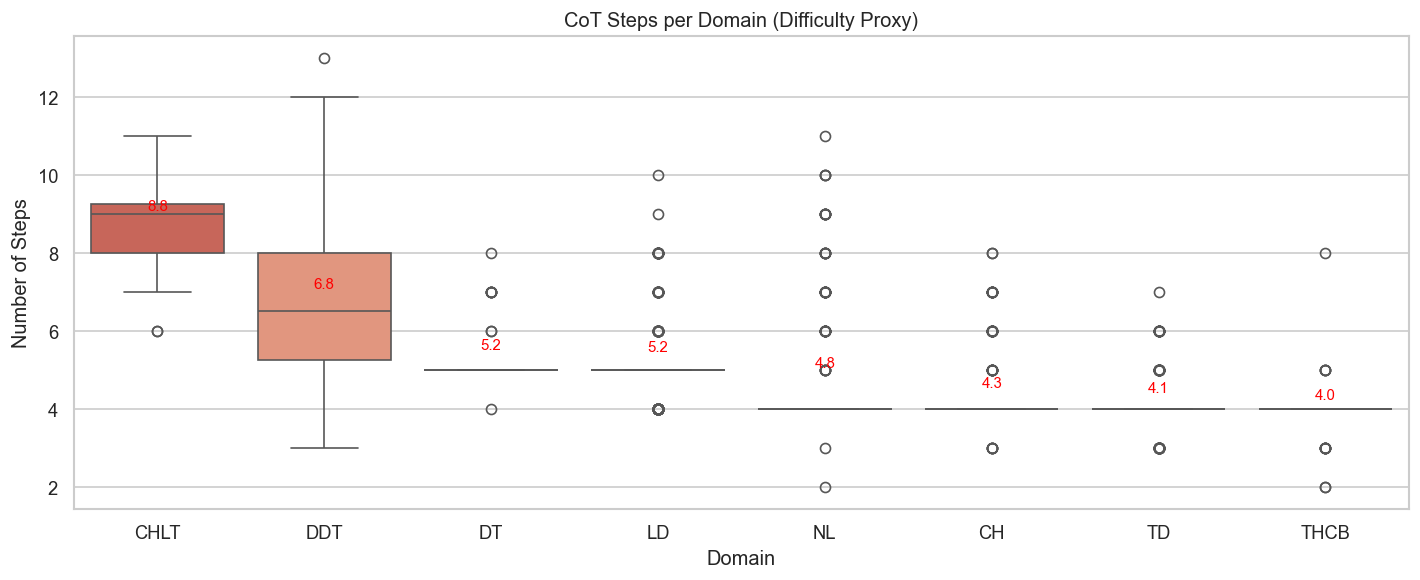

=== Average CoT Steps (Difficulty Ranking) ===
  CHLT  : 8.8 steps (n=20)
  DDT   : 6.8 steps (n=130)
  DT    : 5.2 steps (n=68)
  LD    : 5.2 steps (n=397)
  NL    : 4.8 steps (n=190)
  CH    : 4.3 steps (n=290)
  TD    : 4.1 steps (n=177)
  THCB  : 4.0 steps (n=80)


In [17]:
# CoT steps per domain — difficulty proxy
fig, ax = plt.subplots(figsize=(12, 5))

domain_order = df.groupby("prefix")["cot_steps"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="prefix", y="cot_steps", order=domain_order, ax=ax, palette="coolwarm_r")
ax.set_title("CoT Steps per Domain (Difficulty Proxy)")
ax.set_ylabel("Number of Steps")
ax.set_xlabel("Domain")

# Annotate means
means = df.groupby("prefix")["cot_steps"].mean()
for i, prefix in enumerate(domain_order):
    ax.text(i, means[prefix] + 0.3, f"{means[prefix]:.1f}", ha="center", fontsize=9, color="red")

plt.tight_layout()
plt.savefig("../../app/figures/EDA_difficulty_proxy.png", bbox_inches="tight")
plt.show()

print("=== Average CoT Steps (Difficulty Ranking) ===")
for prefix in domain_order:
    n = len(df[df["prefix"] == prefix])
    print(f"  {prefix:6s}: {means[prefix]:.1f} steps (n={n})")

---
## 7. Scientific Notation Deep-dive

237 answers use scientific notation — but in **multiple incompatible formats**.

In [18]:
sci = df[df["answer_type"] == "scientific_notation"].copy()
print(f"Scientific notation answers: {len(sci)}")
print(f"By domain: {sci['prefix'].value_counts().to_dict()}")
print()

# Classify notation format
def classify_sci_format(ans):
    ans = str(ans)
    if "10^" in ans and "×" in ans:
        return "N × 10^M (caret + ×)"
    if "10^" in ans and "*" in ans:
        return "N * 10^M (caret + *)"
    if "10^" in ans:
        return "N 10^M (caret, other)"
    if re.search(r"10[\u2070-\u2079\u207B]", ans):
        if "×" in ans:
            return "N × 10ˢᵘᵖ (superscript + ×)"
        return "N 10ˢᵘᵖ (superscript, other)"
    if "x 10" in ans.lower():
        return "N x 10^M (lowercase x)"
    return "other"

sci["sci_format"] = sci["answer"].apply(classify_sci_format)
print("=== Scientific Notation Formats ===")
for fmt, cnt in sci["sci_format"].value_counts().items():
    example = sci[sci["sci_format"] == fmt]["answer"].iloc[0]
    print(f"  {fmt:35s} {cnt:4d}  e.g. {example}")

Scientific notation answers: 237
By domain: {'LD': 191, 'DT': 23, 'DDT': 21, 'TD': 2}

=== Scientific Notation Formats ===
  N × 10^M (caret + ×)                  98  e.g. 24.45 × 10^-3
  N * 10^M (caret + *)                  87  e.g. 2.707*10^-3
  N × 10ˢᵘᵖ (superscript + ×)           31  e.g. 4.0 × 10⁴
  N 10^M (caret, other)                 21  e.g. 1.218 x 10^-3


---
## 8. Token Budget Estimation

In [19]:
# Rough estimation: 1 token ≈ 4 characters for English text
df["q_tokens_est"] = df["q_len"] / 4
df["cot_tokens_est"] = df["cot_len"] / 4
df["total_tokens_est"] = df["q_tokens_est"] + df["cot_tokens_est"]

print("=== Token Budget Estimation (chars/4) ===")
for col, label in [("q_tokens_est", "Question"), ("cot_tokens_est", "CoT"), ("total_tokens_est", "Total")]:
    print(f"  {label:10s}: mean={df[col].mean():.0f}, p50={df[col].median():.0f}, p95={df[col].quantile(0.95):.0f}, max={df[col].max():.0f}")

print(f"\n  Qwen3.5-4B context: 262,144 tokens")
print(f"  P95 input+output: ~{df['total_tokens_est'].quantile(0.95):.0f} tokens")
print(f"  Remaining for few-shot + system prompt: ~{262144 - df['total_tokens_est'].quantile(0.95):.0f} tokens")
print(f"  → Plenty of room for RAG context, few-shot examples, and tool call logs.")

=== Token Budget Estimation (chars/4) ===
  Question  : mean=43, p50=39, p95=76, max=123
  CoT       : mean=145, p50=120, p95=296, max=437
  Total     : mean=188, p50=165, p95=350, max=520

  Qwen3.5-4B context: 262,144 tokens
  P95 input+output: ~350 tokens
  Remaining for few-shot + system prompt: ~261794 tokens
  → Plenty of room for RAG context, few-shot examples, and tool call logs.


---
## 9. Duplicate & Edge Case Check

In [20]:
# Duplicate questions
dup_mask = df["question"].duplicated(keep=False)
dups = df[dup_mask].sort_values("question")
print(f"=== Duplicate Questions: {len(dups)} rows ({dups['question'].nunique()} unique) ===")
for q in dups["question"].unique():
    rows = dups[dups["question"] == q][["id", "answer", "unit"]]
    print(f"\n  Q: \"{q[:120]}...\"")
    for _, r in rows.iterrows():
        print(f"    {r['id']}: answer={r['answer']}, unit={r['unit']}")

=== Duplicate Questions: 4 rows (2 unique) ===

  Q: "A capacitor with a capacitance of 5 μF is charged to a voltage of 20 V and then disconnected from the power source. Calc..."
    TD368: answer=100, unit=μC
    TD369: answer=Do not change, unit=nan

  Q: "Three identical charges, q = 1.2 × 10^-6 C, are placed at the three vertices of an isosceles right triangle with legs of..."
    LD302: answer=5.65 × 10^6, unit=V/m
    LD303: answer=7.95 × 10^6, unit=V/m


In [21]:
# Negative and zero answers
neg = df[df["answer_numeric"] < 0]
zero = df[df["answer_numeric"] == 0]

print(f"=== Negative answers: {len(neg)} ===")
if len(neg) > 0:
    print(neg[["id", "answer", "unit", "prefix"]].to_string())

print(f"\n=== Zero answers: {len(zero)} ===")
if len(zero) > 0:
    print(zero[["id", "answer", "unit", "prefix"]].head(10).to_string())

=== Negative answers: 1 ===
        id answer unit prefix
632  TD391  -1.77   μJ     TD

=== Zero answers: 18 ===
        id answer unit prefix
37   LD036      0    N     LD
40   LD039      0    N     LD
43   LD042      0    N     LD
44   LD043      0    N     LD
60   LD059      0  V/m     LD
80   LD079      0  V/m     LD
85   LD084      0  V/m     LD
95   LD095      0  V/m     LD
96   LD096      0  V/m     LD
201  DT001      0  V/m     DT


In [22]:
# Vietnamese remnants
viet_in_ans = df[df["answer"].str.contains("lần|Hướng|phía|Độ", na=False, regex=True)]
viet_in_unit = df[df["unit"].str.contains("lần|Độ", na=False, regex=True)]

print(f"=== Vietnamese in Answers: {len(viet_in_ans)} ===")
if len(viet_in_ans) > 0:
    print(viet_in_ans[["id", "answer", "unit"]].to_string())

print(f"\n=== Vietnamese in Units: {len(viet_in_unit)} ===")
if len(viet_in_unit) > 0:
    print(viet_in_unit[["id", "answer", "unit"]].to_string())

=== Vietnamese in Answers: 1 ===
       id            answer unit
48  LD047  Hướng về phía q₂    -

=== Vietnamese in Units: 2 ===
        id answer unit
608  TD367      4  lần
808  NL127      4  lần


---
## 10. Summary & Recommendations

### Key Findings

| # | Finding | Impact | Action |
|---|---|---|---|
| 1 | **28% answers are non-numeric** (sci notation, text, Yes/No, multi-value) | Pipeline CANNOT just output float+unit | Build answer type classifier + routing |
| 2 | **Scientific notation has 2+ incompatible formats** (`10^-3` vs `10⁻³`) | Parsing/evaluation will fail | Standardize to single format |
| 3 | **CHLT is 100% Yes/No** (20 samples) | Different strategy needed | Rule-based or formula-check approach |
| 4 | **THCB has 29% multi-value** (`val1; val2` with `unit1; unit2`) | Special output parsing needed | Multi-value parser |
| 5 | **55 unique units** with encoding inconsistencies | Training noise | Normalize all units |
| 6 | **20x domain imbalance** (LD=397 vs CHLT=20) | Model bias | Data augmentation for small domains |
| 7 | **14 null units, 3 Vietnamese remnants** | Incomplete data | Fix manually |
| 8 | **Token budget is comfortable** (P95 ~350 tokens) | No context window issues | Use generous few-shot + tool logs |
| 9 | **CHLT easiest domain by CoT steps but DDT most complex** | Difficulty varies widely | Domain-aware prompting |
| 10 | **CoT quality uncertain** (machine-generated, known errors) | Training on bad CoT = bad model | Re-generate with commercial LLM + SymPy verify |

In [23]:
# Final summary table
summary = pd.DataFrame({
    "Domain": sorted(df["prefix"].unique()),
    "Count": [len(df[df["prefix"]==p]) for p in sorted(df["prefix"].unique())],
    "% of Total": [f"{len(df[df['prefix']==p])/len(df)*100:.1f}%" for p in sorted(df["prefix"].unique())],
    "Avg CoT Steps": [df[df["prefix"]==p]["cot_steps"].mean().round(1) for p in sorted(df["prefix"].unique())],
    "% Numeric": [f"{len(df[(df['prefix']==p) & (df['answer_type']=='pure_numeric')])/len(df[df['prefix']==p])*100:.0f}%" for p in sorted(df["prefix"].unique())],
    "Top Unit": [df[df["prefix"]==p]["unit"].value_counts().index[0] if df[df["prefix"]==p]["unit"].notna().any() else "NaN" for p in sorted(df["prefix"].unique())],
    "Key Challenge": [
        "RLC circuits, many formulas",       # CH
        "100% Yes/No, only 20 samples",       # CHLT
        "Most complex, mixed answer types",   # DDT
        "Long questions, field calculations",  # DT
        "48% scientific notation, largest",    # LD
        "10% text answers, energy domain",     # NL
        "Capacitor calcs, straightforward",    # TD
        "29% multi-value, error analysis",     # THCB
    ]
})
summary

,Domain,Count,% of Total,Avg CoT Steps,% Numeric,Top Unit,Key Challenge
0,CH,290,21.4%,4.3,100%,W,"RLC circuits, many formulas"
1,CHLT,20,1.5%,8.8,0%,-,"100% Yes/No, only 20 samples"
2,DDT,130,9.6%,6.8,60%,—,"Most complex, mixed answer types"
3,DT,68,5.0%,5.2,57%,V/m,"Long questions, field calculations"
4,LD,397,29.4%,5.2,51%,N,"48% scientific notation, largest"
5,NL,190,14.1%,4.8,84%,J,"10% text answers, energy domain"
6,TD,177,13.1%,4.1,94%,nC,"Capacitor calcs, straightforward"
7,THCB,80,5.9%,4.0,49%,%,"29% multi-value, error analysis"
